In [1]:
import pandas as pd
import numpy as np
import os, glob, pysam



# 22 vs 6
comparison = "22vs5"
TN_list = ["190426_FFT", "190426_PCT", "190426_PFT", "190426_PP", "190426_PT", "230802_2", "230419", "241023", "221102", "240403_3", "240412_2", "230127", "190524", "240320", "231025", "230323_2", "230323_11", "230920", "230822",
     "230405_2", "221202", "231006" ]
PC_list = [ "221026", "240110", "220930_1", "241016", "250212" ]

comparison = "23vs5"
TN_list = ["190426_FFT", "190426_PCT", "190426_PFT", "190426_PP", "190426_PT", "230802_2", "230419", "241023", "221102", "240403_3", "240412_2", "230127", "190524", "240320", "231025", "230323_2", "230323_11", "230920", "230822",
     "230405_2", "221202", "231006", "241127" ]
PC_list = [ "221026", "240110", "220930_1", "241016", "250212" ]

# Solitary만 선택 : 14 vs 5
comparison = "14vs5_only_solitary"
TN_list = [ "230802_2", "230419", "241023", "221102", "240403_3", "240412_2", "230127", "190524", "240320", "231025",  "230822", "230405_2", "221202", "231006" ]
PC_list = [ "221026", "240110", "220930_1", "241016", "250212" ]

sample_list = TN_list + PC_list

### Parsing Sequenza segment

In [2]:
INPUT_DIR="/data/project/Meningioma/11.cnv/2.sequenza/hg38"
OUTPUT_CNV_DIR="/data/project/Meningioma/32.Infiltration_score/01.TINC/01.Input/01.CNV"

if not os.path.exists(OUTPUT_CNV_DIR):
    os.makedirs(OUTPUT_CNV_DIR)

for Sample_ID in sample_list:
    for TISSUE in ["Tumor"]:
        if os.path.exists("{}/{}/{}/{}_{}_segments.txt".format(INPUT_DIR, Sample_ID, TISSUE, Sample_ID, TISSUE)):
            data = pd.read_csv("{}/{}/{}/{}_{}_segments.txt".format(INPUT_DIR, Sample_ID, TISSUE, Sample_ID, TISSUE) , sep="\t")
            cnv = []
            for i in range(len(data)):
                record = data.iloc[i, :]
                cnv.append({
                    "chr": record["chromosome"],  "from": record["start.pos"], "to": record["end.pos"],   "length": record["end.pos"] - record["start.pos"] + 1,
                    "covRatio": record["depth.ratio"],  "Major": record["A"],  "minor": record["B"]
                })
        
            cnv_df = pd.DataFrame(cnv)
            cnv_df.to_csv( "{}/{}.tsv".format (OUTPUT_CNV_DIR , Sample_ID), index = False, sep="\t" )

            print ( "{} is done".format (Sample_ID) )

230419 is done
241023 is done
221102 is done
240403_3 is done
240412_2 is done
230127 is done
190524 is done
231025 is done
230822 is done
230405_2 is done
221202 is done
231006 is done
221026 is done
240110 is done
220930_1 is done
241016 is done
250212 is done


### Parsing Mutect2 output  (하나의 TSV에 tumor_ref, tumor_alt, dura_ref, dura_alt를 적어줌 )

In [3]:
OUTPUT_SNV_DIR="/data/project/Meningioma/32.Infiltration_score/01.TINC/01.Input/02.SNV"

for DIR in [OUTPUT_SNV_DIR]:
    if not os.path.exists(DIR):
        os.makedirs (DIR)

for Sample_ID in sample_list:
    tumor_vcf = pysam.VariantFile (  "/data/project/Meningioma/04.mutect/02.PASS/{}_Tumor.MT2.FMC.HF.RMBLACK.vcf.gz".format(Sample_ID)   )
    for TISSUE in [ "DT", "Dura", "Falx", "Falx_1", "Falx_2" ]:
        if os.path.exists ( "/data/project/Meningioma/04.mutect/04.Other_rescue/{}_{}.MT2.FMC.HF.RMBLACK.rescue.vcf.gz".format(Sample_ID, TISSUE) ):
            dura_vcf = pysam.VariantFile(  "/data/project/Meningioma/04.mutect/04.Other_rescue/{}_{}.MT2.FMC.HF.RMBLACK.rescue.vcf.gz".format(Sample_ID, TISSUE) )
            if  ("190426" in Sample_ID) or ("241127" in Sample_ID):
                dura_bam_path = "/data/project/Meningioma/02.Align/hg38/Dura/05.Final_bam/{}_{}.bam".format(Sample_ID.split("_")[0], TISSUE)
            else:
                dura_bam_path = "/data/project/Meningioma/02.Align/hg38/Dura/05.Final_bam/{}_{}.bam".format(Sample_ID, TISSUE)
            break

    #1. Tumor, Normal VCF를 parsing해서 merged_df 생성
    tumor_profiles = []
    normal_profiles = []

    for record in tumor_vcf:
        samples = [s for s in record.samples if "Tumor" in s]
        if len(samples) == 0:
            continue
        sample_id = samples[0]

        ad = record.samples[sample_id]["AD"]
        tumor_profiles.append ( [   record.contig,  record.pos - 1,  record.pos,  record.ref,  record.alts[0], ad[0],  ad[1]] )

    for record in dura_vcf:
        samples = [s for s in record.samples if ("Dura" in s or "Falx" in s or "DT" in s)]
        if len(samples) == 0:
            continue
        sample_id = samples[0]

        ad = record.samples[sample_id]["AD"]
        normal_profiles.append([  record.contig,  record.pos - 1,  record.pos,   record.ref,  record.alts[0],  ad[0],  ad[1] ] )

    tumor_df = pd.DataFrame ( tumor_profiles,  columns=["chr", "from", "to", "ref", "alt", "t_ref_count", "t_alt_count"] )
    normal_df = pd.DataFrame(  normal_profiles, columns=["chr", "from", "to", "ref", "alt", "n_ref_count", "n_alt_count"] )

    merged_df = pd.merge ( tumor_df,  normal_df,  on=["chr", "from", "to", "ref", "alt"], how="left" )


    #2. Tumor only call에 대해서는 Normal bam에서 depth를 가져오고 alt = 0으로 처리
    dura_bam = pysam.AlignmentFile (dura_bam_path, "rb")

    for j in range(len(merged_df)):
        record = merged_df.iloc[j, :]

        if np.isnan(record["n_ref_count"]):
            reads = list(dura_bam.fetch(record["chr"], record["from"], record["to"]))

            merged_df.loc[j, "n_ref_count"] = len(reads)
            merged_df.loc[j, "n_alt_count"] = 0

    merged_df["n_ref_count"] = merged_df["n_ref_count"].astype(int)
    merged_df["n_alt_count"] = merged_df["n_alt_count"].astype(int)

    
    merged_df.to_csv ( "{}/{}.SNV_profile.tsv".format (OUTPUT_SNV_DIR, Sample_ID) , sep="\t", index=False)

    merged_df.columns =  [ "chr", "from", "to", "ref", "alt", "t_ref_count", "t_alt_count", "n_ref_count", "n_alt_count"  ]
    merged_df.to_csv ( "{}/{}.tsv".format (OUTPUT_SNV_DIR, Sample_ID), sep="\t", index=False)

    print ( "{} is done".format (Sample_ID) )


230802_2 is done
230419 is done
241023 is done
221102 is done
240403_3 is done
240412_2 is done
230127 is done
190524 is done
240320 is done
231025 is done
230822 is done
230405_2 is done
221202 is done
231006 is done
221026 is done
240110 is done
220930_1 is done
241016 is done
250212 is done


---

# Run TINC

In [4]:
logPath = "/data/project/Meningioma/script/32.Infiltration_score/log"
if not os.path.exists(logPath):
    os.makedirs(logPath, exist_ok=True)



for Sample_ID in sample_list:
    SNV_INPUT =  "{}/{}.tsv".format (OUTPUT_SNV_DIR , Sample_ID)
    CNV_INPUT =  "{}/{}.tsv".format (OUTPUT_CNV_DIR , Sample_ID)
    OUTPUT_PATH ="/data/project/Meningioma/32.Infiltration_score/01.TINC/02.Output/{}/TINC_output.tsv".format(Sample_ID)
    OUTPUT_PLOT_DIR ="/data/project/Meningioma/32.Infiltration_score/01.TINC/02.Output/{}".format(Sample_ID)
    MIN_VAF = 0.01
    N_cutoff = 10
    pi_cutoff = 0.03

    command = (
        f"sbatch --job-name='TINC_{Sample_ID}' "
        f"--output={logPath}/{Sample_ID}.log "
        f"--error={logPath}/{Sample_ID}.err "
        f"--cpus-per-task=11 --mem-per-cpu=16GB --time=1:00:00 --partition=cpu --qos nstumor "
        f" --wrap=\"/data/project/Meningioma/script/32.Infiltration_score/TINC_pipe_02.run.sh "
        f"--Sample_ID {Sample_ID} "
        f"--MIN_VAF {MIN_VAF} "
        f"--N_cutoff {N_cutoff} "
        f"--pi_cutoff {pi_cutoff} "
        f"--SNV_INPUT {SNV_INPUT} "
        f"--CNV_INPUT {CNV_INPUT} "
        f"--OUTPUT_PATH {OUTPUT_PATH} "
        f"--OUTPUT_PLOT_DIR {OUTPUT_PLOT_DIR}\""
    )

    os.system(command)






Submitted batch job 50114
Submitted batch job 50115
Submitted batch job 50116
Submitted batch job 50117
Submitted batch job 50118
Submitted batch job 50119
Submitted batch job 50120
Submitted batch job 50121
Submitted batch job 50122
Submitted batch job 50123
Submitted batch job 50124
Submitted batch job 50125
Submitted batch job 50126
Submitted batch job 50127
Submitted batch job 50128
Submitted batch job 50129
Submitted batch job 50130
Submitted batch job 50131
Submitted batch job 50132


---

## Visualization

In [5]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import palettable, os, glob
import warnings
from scipy.stats import mannwhitneyu, ttest_ind
file_paths = glob.glob( "/home/goldpm1/miniconda3/envs/cnvpytor/lib/python3.7/site-packages/matplotlib/mpl-data/fonts/ttf/ARIAL*" )
absolute_file_paths = [os.path.abspath(file_path) for file_path in file_paths]
for absolute_file_path in absolute_file_paths:
    mpl.font_manager.fontManager.addfont( absolute_file_path )
plt.rcParams["font.family"] = 'Arial'

warnings.filterwarnings("ignore")




df = pd.DataFrame ( columns = ["Sample","TINC_score", "Sample_Type"] )

for Sample_ID in sample_list:
    TINC_OUTPUT_PATH = "/data/project/Meningioma/32.Infiltration_score/01.TINC/02.Output/{}/TINC_output.tsv".format(Sample_ID)
    if os.path.exists(TINC_OUTPUT_PATH) == False:
        print ( "{} is not completed".format(Sample_ID) )
        continue

    df_temp = pd.read_csv(TINC_OUTPUT_PATH, sep="\t" )
    k = "meningeal_mosaicism" if Sample_ID in TN_list else "tumor_infiltration"

    df = df.append ( {"Sample": Sample_ID, "TINC_score": df_temp["TumorInNormal"].iloc[0], "Sample_Type": k}, ignore_index=True )

df

230802_2 is not completed


,Sample,TINC_score,Sample_Type
0,230419,0.000791,meningeal_mosaicism
1,241023,0.000000,meningeal_mosaicism
2,221102,0.000000,meningeal_mosaicism
3,240403_3,0.000000,meningeal_mosaicism
4,240412_2,0.003247,meningeal_mosaicism
5,230127,0.002188,meningeal_mosaicism
6,190524,0.001790,meningeal_mosaicism
7,240320,0.000690,meningeal_mosaicism
8,231025,0.011635,meningeal_mosaicism
9,230822,0.003634,meningeal_mosaicism


comparison : 14vs5_only_solitary


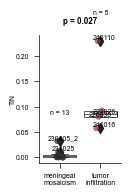

In [6]:
def DRAW_TINC_BOXPLOT ( ax, df_inside, x, y, hue, **kwargs ):
    box = sns.boxplot ( data = df_inside, x = x, y = y, hue = x, palette = kwargs["palette"], linewidth = kwargs["linewidth"], dodge = False, ax = ax )
    for i, patch in enumerate(box.patches):
        patch.set_facecolor('none')
    #sns.swarmplot ( data = df_inside, x = x, y = y, hue = x, palette = kwargs["palette"], linewidth = kwargs["linewidth"], dodge = False, ax = ax )
    sns.stripplot (  data=df_inside,  x=x, y=y, hue=hue,  palette=kwargs["palette"],  dodge=False, jitter=True,  size = kwargs.get("strip_size", 4),   marker=kwargs.get("strip_marker", "o"), linewidth=0.3, edgecolor="gray",  alpha=0.7,    ax=ax  )


    # outlier에 Sample_ID 텍스트 추가
    for i, group in enumerate(df_inside[x].unique()):
        group_data = df_inside[df_inside[x] == group]    
        # IQR 계산하여 outlier 찾기
        if group == "meningeal_mosaicism":
            Q1 = group_data[y].quantile(0.001)    
            Q3 = group_data[y].quantile(0.8)
        else:
            Q1 = group_data[y].quantile(0.55)
            Q3 = group_data[y].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1
        upper_bound = Q3 + 0.5 * IQR
    
        # outlier 찾기
        outliers = group_data[(group_data[y] < lower_bound) | (group_data[y] > upper_bound)]
        for idx, row in outliers.iterrows():
            ax.text(i + 0.1, row[y], row['Sample'],  fontsize = kwargs["label_fontsize"], ha='center', va='bottom')



    # 각 군의 데이터 개수를 계산하고 boxplot 위에 표시
    for j, sample_type in enumerate(df_inside[x].unique()):
        subset = df_inside[df_inside[x] == sample_type]
        count = len(subset.dropna(subset=[y]))  # NaN 값 제외한 개수
        # boxplot 위쪽에 개수 표시
        y_max = subset[y].max() if not subset[y].isna().all() else 0
        ax.text(j, y_max + 0.05, f'n = {count}', 
                ha = 'center', va = 'bottom',  fontsize=kwargs["tick_labelsize"],  fontweight = 'normal' )


    # 두 그룹이 있다고 생각하고 Mann_whitney test
    group_names = df_inside[x].unique()
    if len(group_names) == 2:
        group1 = df_inside[df_inside[x] == group_names[0]][y].dropna()
        group2 = df_inside[df_inside[x] == group_names[1]][y].dropna()
        if len(group1) > 0 and len(group2) > 0:
            stat, pval = mannwhitneyu(group1, group2, alternative="two-sided")
            stat, pval = ttest_ind(group1, group2, equal_var=False)
            y_loc = max(df_inside[y].max(), 0) + 0.03              # p값 표시 위치: y 값의 최대에서 + 0.03 정도 위에 표시 (좌우축 중앙)
            p_text = f'p = {pval:.3e}' if pval < 0.001 else f'p = {pval:.3f}'
            ax.text(0.5, y_loc, p_text, ha='center', va='bottom', fontsize=kwargs["tick_labelsize"]+1, fontweight='bold' )
            #, transform=ax.get_xaxis_transform(which='grid'), clip_on=False)




    
    ax.set_xlabel ( "", fontsize = kwargs["label_fontsize"], fontweight = "normal", labelpad = 0)
    ax.set_ylabel ( "TIN", fontsize = kwargs["label_fontsize"], fontweight = "normal", labelpad = 0)
    ax.tick_params ( axis = 'both', labelsize = kwargs["tick_labelsize"], width = kwargs["linewidth"]  )

    # ax.set_xticklabels에서 "_"를 "\n"으로 치환해서 줄바꿈으로 해줘
    new_labels = [label.get_text().replace("_", "\n") for label in ax.get_xticklabels()]
    ax.set_xticklabels(new_labels)

    for axis in ['left','bottom']:
        ax.spines[axis].set_linewidth( kwargs["linewidth"] )
    for axis in ['right','top']:
        ax.spines[axis].set_linewidth( 0 )

    ax.get_legend().remove()
    
    return ax


########################################################################################################################################################



kwargs = { "figsize": (1.1 , 1.6), "label_fontsize": 6, "labelpad": 0, "tick_labelsize": 6, "linewidth": 0.5, "palette" : [ "#333333", "#A23636"  ],
                     "OUTPUT_PATH": "//data/project/Meningioma/32.Infiltration_score/01.TINC/03.Visualization/TINC_boxplot_{}.pdf".format (comparison)}

print ("comparison : {}".format( comparison) )
fig, ax = plt.subplots( nrows = 1, ncols = 1, figsize = kwargs["figsize"] )
fig.subplots_adjust ( wspace = 0.8, bottom = 0.18, top = 0.98, left = 0.2, right = 0.94 )
ax = DRAW_TINC_BOXPLOT ( ax, df, x="Sample_Type", y="TINC_score", hue="Sample_Type", **kwargs)


fig.savefig ( kwargs["OUTPUT_PATH"], dpi = 300, bbox_inches = "tight" )
fig.show()